# Сравнение умножения матриц на CPU и GPU

В этой работе выполняется несколько экспериментов для матриц разных размеров. Для каждого размера измеряется время работы нескольких реализаций и вычисляется ускорение относительно наивной CPU-версии.

Также, в рамках личного интереса, проводились сравнения с функциями библиотек NumPy и PyTorch, т.к. по другим предметам я использовал их чаще собственной реализации.

P.S. За CPU реализацию была взята стандартная формула перемножения матриц. Ничего не оптимизировано, поэтому далее буду называть её наивной

# 1. Импорт библиотек и задание размеров

Подключаем необходимые библиотеки и задаем список размеров квадратных матриц, на которых будет проводиться эксперимент.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from numba import cuda

np.random.seed(42)

sizes = [100] + np.arange(500, 2001, 500).tolist()
dtype = np.float32

print("Размеры матриц:", sizes)
print("Numba CUDA доступна:", cuda.is_available())
print("PyTorch CUDA доступна:", torch.cuda.is_available())

Размеры матриц: [100, 500, 1000, 1500, 2000]
Numba CUDA доступна: True
PyTorch CUDA доступна: True


# 2. Функции вычисления произведения матриц

## 2.1. Функция наивного умножения на CPU

Здесь используется классический алгоритм с тремя вложенными циклами. Именно относительно этого варианта будет считаться ускорение.

In [3]:
def benchmark_cpu(A, B):
    n, m = A.shape
    k = B.shape[1]
    C = np.zeros((n, k), dtype=A.dtype)

    start = time.perf_counter()
    for i in range(n):
        for j in range(k):
            s = 0.0
            for t in range(m):
                s += A[i, t] * B[t, j]
            C[i, j] = s
    end = time.perf_counter()

    return end - start, C

## 2.2. Функция умножения через NumPy

Эта реализация использует готовую оптимизированную функцию `np.dot`, которая обычно работает значительно быстрее наивного варианта.

In [4]:
def benchmark_numpy(A, B):
    start = time.perf_counter()
    C = np.dot(A, B)
    end = time.perf_counter()

    return end - start, C

## 2.3 CUDA

### 2.3.1 CUDA-ядро для Numba

Это ядро вычисляет один элемент результирующей матрицы на одном GPU-потоке.

In [2]:
@cuda.jit
def matmul_kernel(A, B, C):
    i, j = cuda.grid(2)
    if i < C.shape[0] and j < C.shape[1]:
        s = 0.0
        for t in range(A.shape[1]):
            s += A[i, t] * B[t, j]
        C[i, j] = s

### 2.3.2 Функция умножения через Numba CUDA

Матрицы копируются на GPU, затем запускается CUDA-ядро. Если CUDA недоступна, функция возвращает пустой результат.

In [5]:
def benchmark_numba_cuda(A, B):
    if not cuda.is_available():
        return np.nan, None

    n = A.shape[0]
    k = B.shape[1]
    threadsperblock = (16, 16)
    blockspergrid = (
        (n + threadsperblock[0] - 1) // threadsperblock[0],
        (k + threadsperblock[1] - 1) // threadsperblock[1]
    )

    A_device = cuda.to_device(A)
    B_device = cuda.to_device(B)
    C_device = cuda.device_array((n, k), dtype=A.dtype)

    cuda.synchronize()
    start = time.perf_counter()
    matmul_kernel[blockspergrid, threadsperblock](A_device, B_device, C_device)
    cuda.synchronize()
    end = time.perf_counter()

    C = C_device.copy_to_host()
    return end - start, C

## 2.4. Функция умножения через PyTorch на GPU

В этом варианте используется библиотека PyTorch. Если CUDA недоступна, функция также возвращает пустой результат.

In [6]:
def benchmark_torch_cuda(A, B):
    if not torch.cuda.is_available():
        return np.nan, None

    device = torch.device("cuda")
    A_t = torch.tensor(A, device=device)
    B_t = torch.tensor(B, device=device)

    torch.cuda.synchronize()
    start = time.perf_counter()
    C_t = torch.matmul(A_t, B_t)
    torch.cuda.synchronize()
    end = time.perf_counter()

    C = C_t.cpu().numpy()
    return end - start, C

# 3. Прогрев GPU

Первый запуск на GPU может включать дополнительные накладные расходы. Поэтому перед основными измерениями выполняется небольшой прогрев.

In [7]:
if cuda.is_available():
    A_test = np.random.rand(16, 16).astype(dtype)
    B_test = np.random.rand(16, 16).astype(dtype)
    benchmark_numba_cuda(A_test, B_test)
    print("Numba CUDA прогрета")

if torch.cuda.is_available():
    A_test = np.random.rand(16, 16).astype(dtype)
    B_test = np.random.rand(16, 16).astype(dtype)
    benchmark_torch_cuda(A_test, B_test)
    print("PyTorch CUDA прогрета")

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Numba CUDA прогрета
PyTorch CUDA прогрета


# 4. Проведение экспериментов

Для каждого размера создаются случайные матрицы, после чего измеряется время работы всех реализаций. Корректность проверяется относительно результата `NumPy`.

In [8]:
results = []

for size in sizes:
    print(f"Эксперимент для матриц {size}x{size}")

    A = np.random.rand(size, size).astype(dtype)
    B = np.random.rand(size, size).astype(dtype)

    time_numpy, C_numpy = benchmark_numpy(A, B)
    time_cpu, C_cpu = benchmark_cpu(A, B)
    time_numba, C_numba = benchmark_numba_cuda(A, B)
    time_torch, C_torch = benchmark_torch_cuda(A, B)

    results.append({
        "Размер": size,
        "Метод": "CPU",
        "Время, сек": time_cpu,
        "Ускорение": 1.0,
        "Корректность": np.allclose(C_cpu, C_numpy, atol=1e-4)
    })

    results.append({
        "Размер": size,
        "Метод": "NumPy",
        "Время, сек": time_numpy,
        "Ускорение": time_cpu / time_numpy if time_numpy > 0 else np.nan,
        "Корректность": True
    })

    results.append({
        "Размер": size,
        "Метод": "GPU (Numba CUDA)",
        "Время, сек": time_numba,
        "Ускорение": time_cpu / time_numba if np.isfinite(time_numba) and time_numba > 0 else np.nan,
        "Корректность": np.allclose(C_numba, C_numpy, atol=1e-3) if C_numba is not None else None
    })

    results.append({
        "Размер": size,
        "Метод": "PyTorch GPU",
        "Время, сек": time_torch,
        "Ускорение": time_cpu / time_torch if np.isfinite(time_torch) and time_torch > 0 else np.nan,
        "Корректность": np.allclose(C_torch, C_numpy, atol=1e-3) if C_torch is not None else None
    })

results_df = pd.DataFrame(results)
results_df["Время, сек"] = results_df["Время, сек"].round(6)
results_df["Ускорение"] = results_df["Ускорение"].round(2)

results_df

Эксперимент для матриц 100x100


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 49 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Эксперимент для матриц 500x500
Эксперимент для матриц 1000x1000
Эксперимент для матриц 1500x1500
Эксперимент для матриц 2000x2000


,Размер,Метод,"Время, сек",Ускорение,Корректность
0,100,CPU,0.224803,1.00,True
1,100,NumPy,0.000089,2511.77,True
2,100,GPU (Numba CUDA),0.000538,417.54,True
3,100,PyTorch GPU,0.002236,100.54,True
4,500,CPU,27.383542,1.00,True
5,500,NumPy,0.001560,17549.05,True
6,500,GPU (Numba CUDA),0.015089,1814.79,True
7,500,PyTorch GPU,0.000696,39321.57,True
8,1000,CPU,218.101942,1.00,True
9,1000,NumPy,0.005468,39887.70,True


# 5. Построение графиков

Первый график показывает зависимость времени выполнения от размера матрицы, а второй - ускорение относительно CPU.

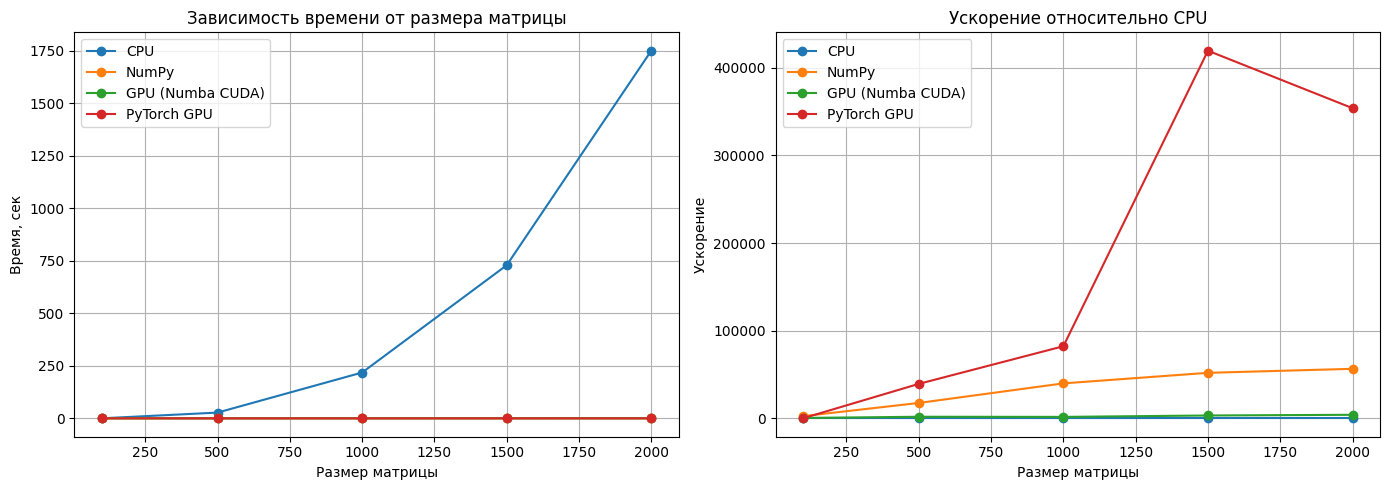

In [10]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for method in results_df["Метод"].unique():
    part = results_df[results_df["Метод"] == method]
    plt.plot(part["Размер"], part["Время, сек"], marker="o", label=method)
plt.xlabel("Размер матрицы")
plt.ylabel("Время, сек")
plt.title("Зависимость времени от размера матрицы")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
for method in results_df["Метод"].unique():
    part = results_df[results_df["Метод"] == method]
    plt.plot(part["Размер"], part["Ускорение"], marker="o", label=method)
plt.xlabel("Размер матрицы")
plt.ylabel("Ускорение")
plt.title("Ускорение относительно CPU")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

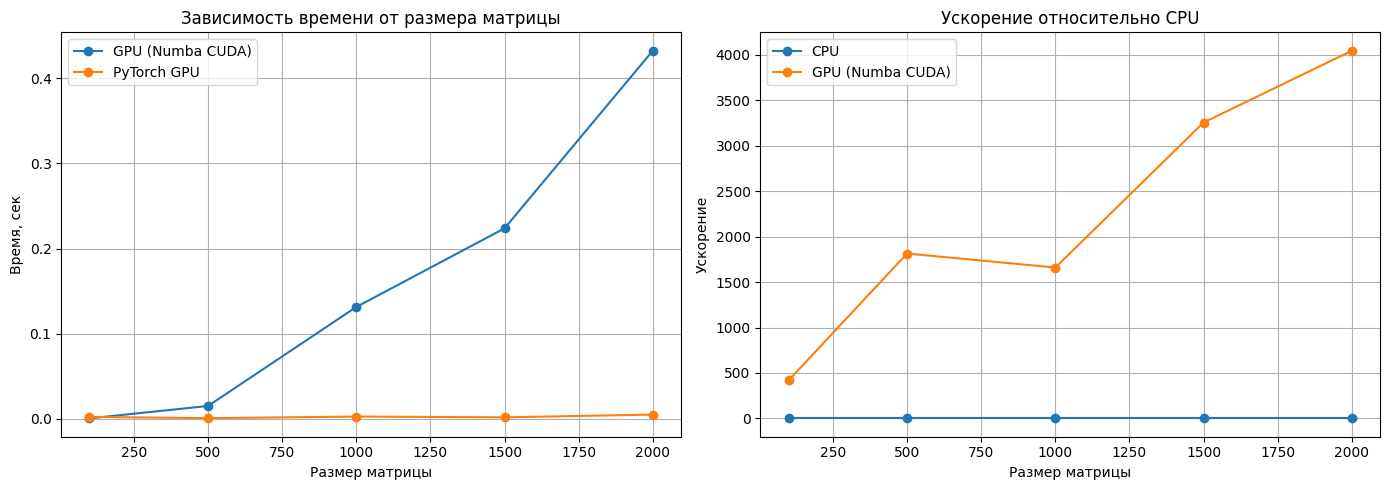

In [18]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for method in results_df["Метод"].unique():
    if method == "CPU":
        continue
    if method == "NumPy":
        continue
    part = results_df[results_df["Метод"] == method]
    plt.plot(part["Размер"], part["Время, сек"], marker="o", label=method)
plt.xlabel("Размер матрицы")
plt.ylabel("Время, сек")
plt.title("Зависимость времени от размера матрицы")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
for method in results_df["Метод"].unique():
    if method == "PyTorch GPU":
        continue
    if method == "NumPy":
        continue
    part = results_df[results_df["Метод"] == method]
    plt.plot(part["Размер"], part["Ускорение"], marker="o", label=method)
plt.xlabel("Размер матрицы")
plt.ylabel("Ускорение")
plt.title("Ускорение относительно CPU")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# 6. Вывод

В результате проведена серия экспериментов для нескольких размеров матриц. Для каждой реализации измерено время работы, рассчитано ускорение относительно наивной CPU-версии и построены таблицы и графики для наглядного сравнения.

PyTorch на GPU, как и ожидалось, показал наилучший результат. NumPy тоже оказался лучше распаралелленной версии наивного вычисления произведения матриц, но не так сильно, как PyTorch.

В сравнении параллельной и обычной версии, параллельная оказалась заметно лучше, что можно заметить по последним графикам